# `jupyter-xarray-titiler` playground

To run this notebook, you'll need the dependencies in this repository's `"play"` dependency group.
For most people, installing the right dependencies might look like:

```bash
uv sync --group dev --group test --group play
```

## First, grab some data and do a calculation on it

We want to see that we can display calculated data from an in-memory dataset.

### Get Sentinel 2 data as an Xarray `DataSet`

In [1]:
import odc.stac
from pystac_client import Client

bbox = [-72.99321, 41.23109, -72.85227, 41.37502]
sentinel2_stac_items = (
    Client.open("https://earth-search.aws.element84.com/v1")
    .search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime="2024-06-01/2024-09-01",
        query={"eo:cloud_cover": {"lt": 20}},
    )
    .item_collection()
)

sentinel2_dataset = odc.stac.load(
    sentinel2_stac_items,
    bands=["red", "green", "blue", "nir08"],
    bbox=bbox,
    resolution=10,
    groupby="solar_day",
    chunks={},
)
sentinel2_dataset

<xarray.Dataset> Size: 64MB
Dimensions:      (y: 1627, x: 1220, time: 4)
Coordinates:
  * y            (y) float64 13kB 4.583e+06 4.583e+06 ... 4.566e+06 4.566e+06
  * x            (x) float64 10kB 6.678e+05 6.678e+05 ... 6.8e+05 6.8e+05
  * time         (time) datetime64[ns] 32B 2024-06-15T15:51:53.600000 ... 202...
    spatial_ref  int32 4B 32618
Data variables:
    red          (time, y, x) uint16 16MB dask.array<chunksize=(1, 1627, 1220), meta=np.ndarray>
    green        (time, y, x) uint16 16MB dask.array<chunksize=(1, 1627, 1220), meta=np.ndarray>
    blue         (time, y, x) uint16 16MB dask.array<chunksize=(1, 1627, 1220), meta=np.ndarray>
    nir08        (time, y, x) uint16 16MB dask.array<chunksize=(1, 1627, 1220), meta=np.ndarray>

### Visualize raw data in RGB

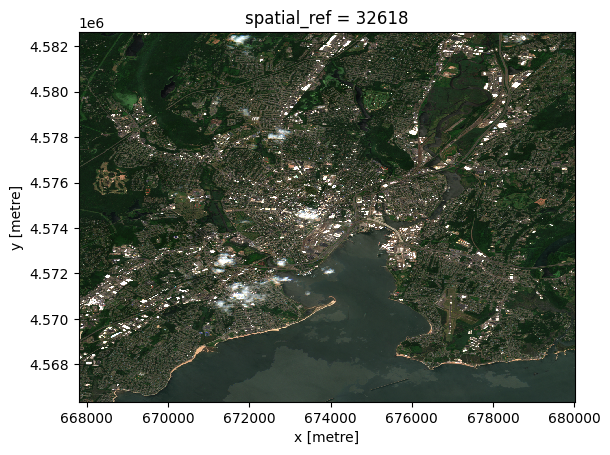

In [2]:
rgb = sentinel2_dataset[["red", "green", "blue"]].to_array(dim="band").median("time")
rgb_scaled = (rgb / 3000).clip(0, 1)  # Scale and clip for display
rgb_scaled.plot.imshow()

### Calculate NDVI

/home/mfisher/Projects/geojupyter/jupyter-microgis/.venv/lib/python3.14/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


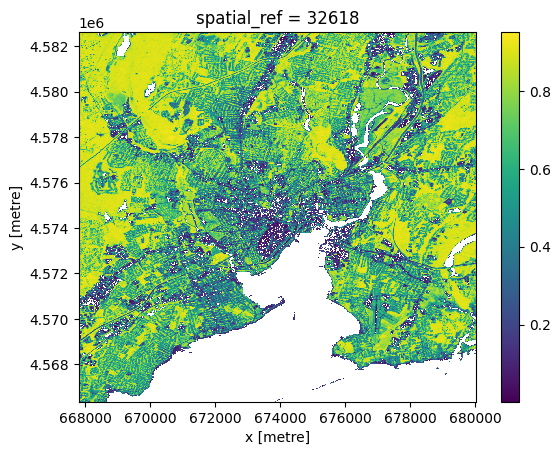

In [3]:
ndvi = (
    (
        (sentinel2_dataset.nir08 - sentinel2_dataset.red)
        / (sentinel2_dataset.red + sentinel2_dataset.nir08)
    )
    .median(
        "time",
        keep_attrs=True,
    )
    .where(lambda ndvi: ndvi < 1)
    .compute()
)

ndvi.plot.imshow();

## Test out `jupyter-server-titiler`

...with the `ndvi` `DataArray` we just calculated!

In [4]:
from jupyter_server_titiler.api import explore

url = await explore(ndvi)
url

[2026-01-27 21:37:55 -0700] [386165] [INFO] Running on http://127.0.0.1:44891 (CTRL + C to quit)


New TiTilerServer instance created
TiTilerServer instance initialized
http://127.0.0.1:44891


'/titiler/58c75495-b535-45a8-a72d-81c15cf8ab00/tiles/WebMercatorQuad/{z}/{x}/{y}.png?scale=1&colormap_name=viridis&reproject=max&name=my_da'

In [5]:
from jupyter_server_titiler.api import TiTilerServer

TiTilerServer()._tile_server_url  # noqa: SLF001
id(TiTilerServer())

Skipping initialization -- it's already been done.
Skipping initialization -- it's already been done.


129458500286992

In [6]:
import leafmap

m = leafmap.Map(center=[41.321482, -72.932739], zoom=10)
m.add_tile_layer(
    url=url,
    name="NH NDVI",
    attribution="Sentinel 2",
)
m

Map(center=[41.321482, -72.932739], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

In [7]:
from jupyter_server.serverapp import list_running_servers
list(list_running_servers())

[{'base_url': '/',
  'hostname': 'localhost',
  'password': False,
  'pid': 385764,
  'port': 8888,
  'root_dir': '/home/mfisher/Projects/geojupyter/jupyter-microgis',
  'secure': False,
  'sock': '',
  'token': '60442b751c965bc157098e65bc81412e8b2d4f14570bec9c',
  'url': 'http://localhost:8888/',
  'version': '2.17.0'}]

In [8]:
from IPython import get_ipython

ipython = get_ipython()
ipython.kernel.config['IPKernelApp']['connection_file']

'/home/mfisher/.local/share/jupyter/runtime/kernel-e1b97a01-b4d8-44f9-9349-bc6639972e29.json'

In [9]:
from jupyter_client import find_connection_file
find_connection_file()

'/home/mfisher/.local/share/jupyter/runtime/kernel-e1b97a01-b4d8-44f9-9349-bc6639972e29.json'